# GAN-PRNG 训练 Notebook

用于训练生成对抗网络以生成高质量随机数

## 配置说明
在下方单元格中修改训练参数

### 1. 导入必要的库

In [1]:
import os
# 改用 Windows 支持的 max_split_size_mb 参数，限制最大内存块大小为 128MB
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'



import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from config import BETAS
# 导入模块化组件
from models import create_model, Generator, Discriminator, GA_Gen_dual, GA_Disc
from trainer import Trainer
from evaluator import AnalyzerRuns
from data_loader import generate_gauss_miu0_sigma1, generate_uniform_int8, generate_uniform_1to1, prepare_batch


#np.random.seed(00)  # 固定种子
#torch.manual_seed(00)
#torch.cuda.manual_seed_all(00)

### 2. 训练参数配置

In [2]:
# ========== 模型配置 ==========
MODEL_TYPE = 2          # 0=基础模型，1=双生成器模型     ---------     增加更多模型        -------
CNN_disc = 1            # 判别器是否包含卷积层
SEQ_LEN = 512          # 生成序列的长度（模型1的GA_Disc仅支持256）
Z_DIM = 64             # 隐变量（噪声）维度

# ========== 训练超参数 ==========
BATCH_SIZE = 512        # 批大小
LR = 0.0001             # 学习率
BETAS = (0.5, 0.999)    #AdamW的 β
EPOCHS = 200000          # 训练轮数
SAVE_INTERVAL = 1000    # 保存权重的间隔
EVAL_INTERVAL = 1000    # 评估间隔

LOSS_TYPE = 5           # 损失模式: 0 = 仅对抗损失 1=+ 串行均匀度 2=+DFT 频谱 3=+ 随机游走 4=+ 线性复杂度 5=+ 均值约束 (target=128) 

# ========== 其他配置 ==========
BIT_MODE = 1            # 0=比特模型，1=int8模式    ---------   注意此模式要与网络匹配     -------
USE_CUDA = True         # 是否使用 CUDA
DATA_type = 'int8'      


# ========== 保存路径 ==========
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXP_NAME = f"GAN_train_{TIMESTAMP}"
CHECKPOINT_DIR = f"./checkpoints/{EXP_NAME}"
LOG_DIR = f"./logs/{EXP_NAME}"

# 设置设备
DEVICE = "cuda" if (torch.cuda.is_available() and USE_CUDA) else "cpu"

print(f"实验名称：{EXP_NAME}")
print(f"使用设备：{DEVICE}")
print(f"模型类型：{MODEL_TYPE}")  #
print(f"检查点保存目录：{CHECKPOINT_DIR}")
print(f"日志目录：{LOG_DIR}")

实验名称：GAN_train_20260709_194644
使用设备：cuda
模型类型：2
检查点保存目录：./checkpoints/GAN_train_20260709_194644
日志目录：./logs/GAN_train_20260709_194644


### 3. 创建模型

In [3]:
# 创建模型
print("正在创建模型...")
generator, discriminator = create_model(
    model_type=MODEL_TYPE,
    device=DEVICE,
    z_dim=Z_DIM,
    seq_len=SEQ_LEN
)

# 打印模型参数量
gen_params = sum(p.numel() for p in generator.parameters())
disc_params = sum(p.numel() for p in discriminator.parameters())

print(f"生成器参数量：{gen_params:,}")
print(f"判别器参数量：{disc_params:,}")
print(f"总参数量：{gen_params + disc_params:,}")

# 打印模型结构（可选）
#print("\n生成器结构:")
#print(generator)
#print("\n判别器结构:")
#print(discriminator)

正在创建模型...
生成器参数量：1,854,464
判别器参数量：567,857
总参数量：2,422,321


### 4. 创建训练器

In [4]:
# 创建训练器
trainer = Trainer(
    generator=generator,
    discriminator=discriminator,
    device=DEVICE,
    lr=LR
)

# 设置 TensorBoard 记录器
trainer.setup_tensorboard(LOG_DIR)
trainer.optimizer_g = optim.AdamW(generator.parameters(), lr=LR, betas=BETAS, weight_decay=1e-4)#或者删掉 默认的是Adam,
trainer.optimizer_d = optim.AdamW(discriminator.parameters(), lr=LR, betas=BETAS, weight_decay=1e-4)
trainer.criterion = nn.MSELoss()  #LSGAN
trainer.loss_type = LOSS_TYPE

print("训练器已创建")
print(f"学习率：{LR}")
print(f"批大小：{BATCH_SIZE}")

TensorBoard 日志目录：./logs/GAN_train_20260709_194644
训练器已创建
学习率：0.0001
批大小：512


### 5. 开始训练

已保存检查点：./checkpoints/GAN_train_20260709_194644\生成器_轮次_200000.pth

训练完成！
模型权重已保存至：./checkpoints/GAN_train_20260709_194644
训练日志已保存至：./logs/GAN_train_20260709_194644

可以使用以下命令查看 TensorBoard:
  tensorboard --logdir=./logs/GAN_train_20260709_194644
TensorBoard 记录器已关闭。
TensorBoard 记录器已关闭。
训练图表已保存至：./training_plot_20260709_194644.png


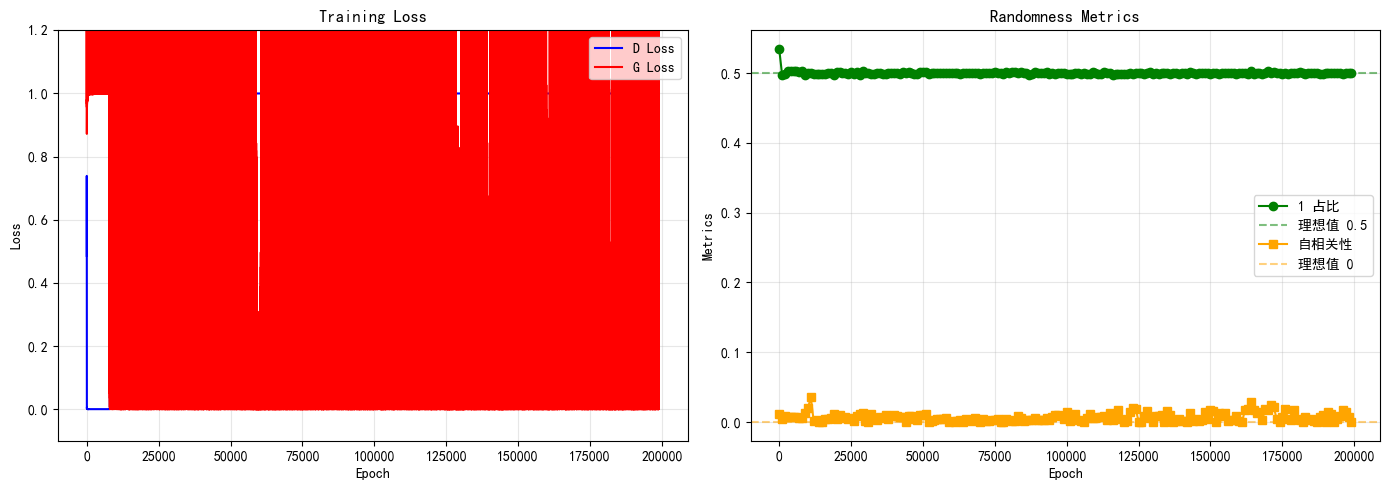

In [5]:
  # 训练历史记录（用于绘图）
d_loss_history = []
g_loss_history = []
metrics_history = []

# 创建进度条和图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.ion()  # 交互模式

print("\n" + "="*50)
print("开始训练 GAN-PRNG")
print("="*50 + "\n")

try:
    for epoch in range(1, EPOCHS + 1):
        # 执行单个训练轮次
        d_loss, g_loss = trainer.train_epoch(
            epoch=epoch,
            batch_size=BATCH_SIZE,
            seq_len=SEQ_LEN,
            z_dim=Z_DIM,
            CNN_disc=1, # model_type=MODEL_TYPE
			data_type=DATA_type
        )
        
        # 记录历史
        d_loss_history.append(d_loss)
        g_loss_history.append(g_loss)
        
        # 定期评估和记录
        if epoch % EVAL_INTERVAL == 1 or epoch == 1:
            # 生成一些数据用于评估
            with torch.no_grad():
                eval_noise = torch.randn(BATCH_SIZE, Z_DIM, device=DEVICE)
                fake_data = generator(eval_noise)


                # 评估并记录
                metrics = trainer.evaluate_and_log(epoch, fake_data, bit_mode=BIT_MODE)
                metrics_history.append(metrics)
            
            # 更新图表
            if epoch % 1000 == 1 or epoch == 1:
                # 损失曲线
                ax1.clear()
                ax1.plot(d_loss_history, label='D Loss', color='blue')
                ax1.plot(g_loss_history, label='G Loss', color='red')
                ax1.set_xlabel('Epoch')
                ax1.set_ylabel('Loss')
                ax1.set_title('Training Loss')
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                ax1.set_ylim(-0.1, 1.2)  # 将 y 轴范围限制在-0.9到1.2 之间
                
                # 随机性指标
                ax2.clear()
                epochs_plot = list(range(1, len(metrics_history) * EVAL_INTERVAL + 1, EVAL_INTERVAL))
                ones_ratio = [m['1 占比'] for m in metrics_history]
                autocorr = [abs(m['自相关性']) for m in metrics_history]
                
                ax2.plot(epochs_plot, ones_ratio, 'o-', label='1 占比', color='green')
                ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='理想值 0.5')
                ax2.plot(epochs_plot, autocorr, 's-', label='自相关性', color='orange')
                ax2.axhline(y=0, color='orange', linestyle='--', alpha=0.5, label='理想值 0')
                ax2.set_xlabel('Epoch')
                ax2.set_ylabel('Metrics')
                ax2.set_title('Randomness Metrics')
                ax2.legend()
                ax2.grid(True, alpha=0.3)
                
                plt.tight_layout()
                display(fig)
                clear_output(wait=True)
        
        # 定期保存模型
        if epoch % SAVE_INTERVAL == 0:
            trainer.save_checkpoint(epoch, CHECKPOINT_DIR)
    
    print("\n训练完成！")
    print(f"模型权重已保存至：{CHECKPOINT_DIR}")
    print(f"训练日志已保存至：{LOG_DIR}")
    print(f"\n可以使用以下命令查看 TensorBoard:")
    print(f"  tensorboard --logdir={LOG_DIR}")

except KeyboardInterrupt:
    print("\n训练被手动停止。")
    print("已训练轮次:", len(d_loss_history))

finally:
    # 关闭 TensorBoard 记录器
    trainer.close()
    print("TensorBoard 记录器已关闭。")

    # 保存最后的图表
    plt.ioff()
    save_path = f"./training_plot_{TIMESTAMP}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"训练图表已保存至：{save_path}")

### 6. 训练结果分析

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

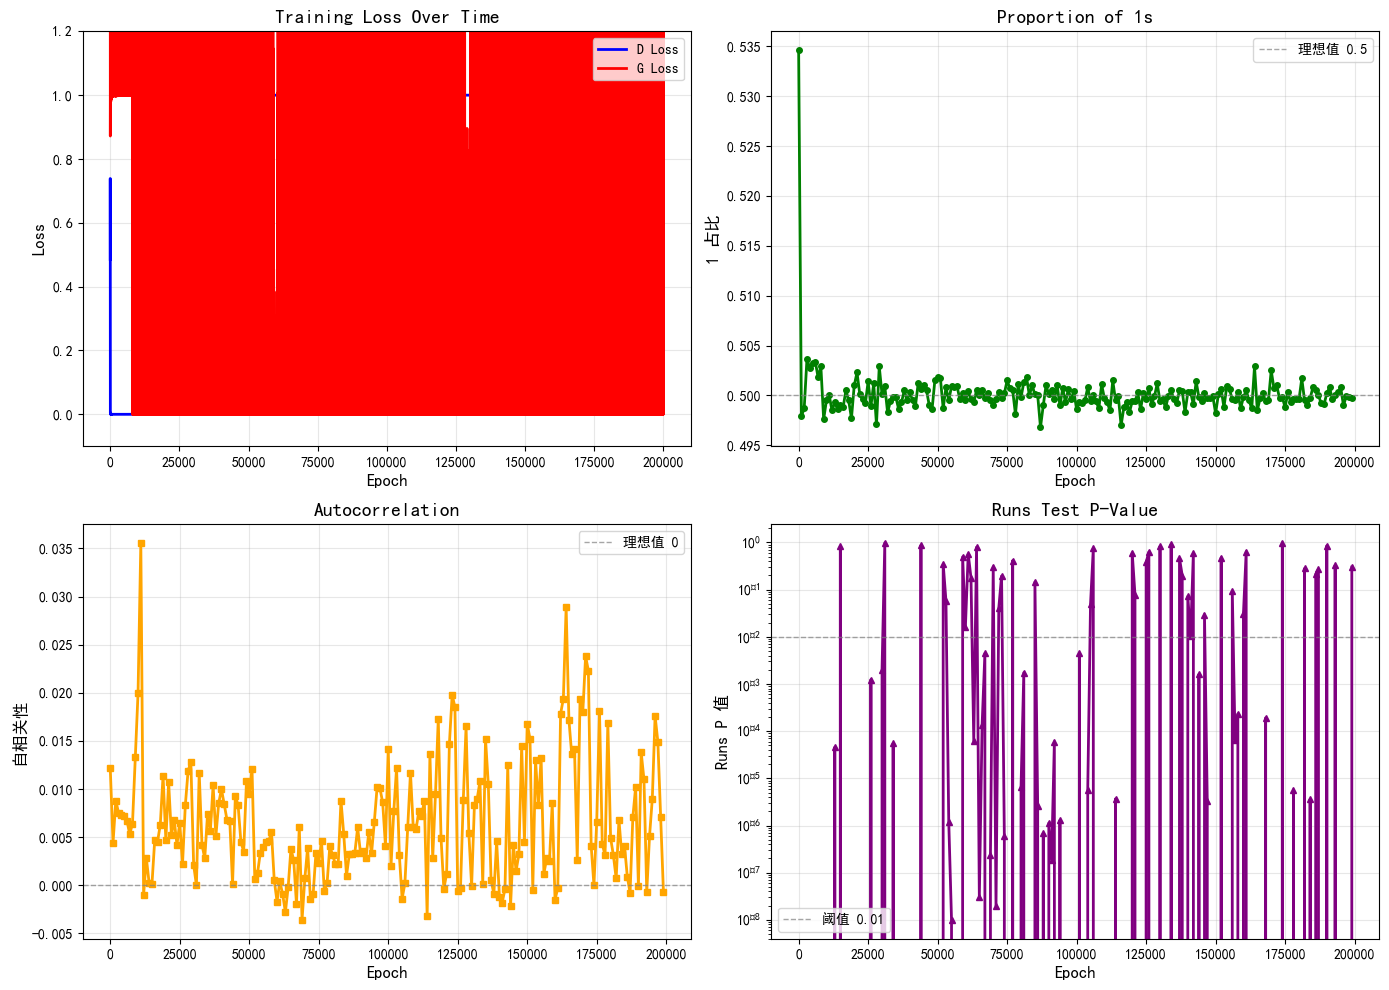


最终随机性指标
1 占比：0.4997 (理想值：0.5)
自相关性：-0.0007 (理想值：0)
Runs_P 值：0.302044 (理想值：>0.01)


In [6]:
# 绘制最终训练结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 损失曲线
ax = axes[0, 0]
ax.plot(d_loss_history, label='D Loss', color='blue', linewidth=2)
ax.plot(g_loss_history, label='G Loss', color='red', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Over Time', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.2)  # 新增这行代码，将 y 轴范围限制在 -0.9 到 1.2 之间

# 2. 1 占比
ax = axes[0, 1]
epochs_plot = list(range(1, len(metrics_history) * EVAL_INTERVAL + 1, EVAL_INTERVAL))
ones_ratio = [m['1 占比'] for m in metrics_history]
ax.plot(epochs_plot, ones_ratio, 'o-', color='green', linewidth=2, markersize=4)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='理想值 0.5')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('1 占比', fontsize=12)
ax.set_title('Proportion of 1s', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 3. 自相关性
ax = axes[1, 0]
autocorr = [m['自相关性'] for m in metrics_history]
ax.plot(epochs_plot, autocorr, 's-', color='orange', linewidth=2, markersize=4)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='理想值 0')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('自相关性', fontsize=12)
ax.set_title('Autocorrelation', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 4. Runs P 值
ax = axes[1, 1]
runs_p = [m['Runs_P 值'] for m in metrics_history]
ax.plot(epochs_plot, runs_p, '^-', color='purple', linewidth=2, markersize=4)
ax.axhline(y=0.01, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='阈值 0.01')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Runs P 值', fontsize=12)
ax.set_title('Runs Test P-Value', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')  # 对数坐标

plt.tight_layout()
plt.show()

# 打印最终指标
if metrics_history:
    final_metrics = metrics_history[-1]
    print("\n" + "="*50)
    print("最终随机性指标")
    print("="*50)
    print(f"1 占比：{final_metrics['1 占比']:.4f} (理想值：0.5)")
    print(f"自相关性：{final_metrics['自相关性']:.4f} (理想值：0)")
    print(f"Runs_P 值：{final_metrics['Runs_P 值']:.6f} (理想值：>0.01)")
    print("="*50)

### 7. 测试生成的随机数

In [7]:
# 使用训练好的模型生成一些随机数并测试
print("使用训练好的生成器测试随机数质量...\n")

generator.eval()
test_samples = []

with torch.no_grad():
    for i in range(10):
        noise = torch.randn(1, Z_DIM, device=DEVICE)
        output = generator(noise)
        metrics = AnalyzerRuns.get_metrics(output, bit_mode=BIT_MODE)
        test_samples.append(metrics)
        print(f"样本 {i+1}: 1 占比={metrics['1 占比']:.4f}, "
              f"自相关性={metrics['自相关性']:.4f}, "
              f"Runs_P 值={metrics['Runs_P 值']:.6f}")

# 计算平均指标
avg_metrics = {
    key: np.mean([m[key] for m in test_samples])
    for key in test_samples[0].keys()
}

print("\n" + "="*50)
print("平均随机性指标 (10 个样本)")
print("="*50)
print(f"1 占比：{avg_metrics['1 占比']:.4f} (理想值：0.5)")
print(f"自相关性：{avg_metrics['自相关性']:.4f} (理想值：0)")
print(f"Runs_P 值：{avg_metrics['Runs_P 值']:.6f} (理想值：>0.01)")
print("="*50)

# 质量评估
print("\n质量评估:")
bias = abs(avg_metrics['1 占比'] - 0.5)
corr = abs(avg_metrics['自相关性'])

if bias < 0.01:
    print("✓ 1 占比非常接近理想值")
elif bias < 0.05:
    print("✓ 1 占比接近理想值")
else:
    print("✗ 1 占比偏离较大")

if corr < 0.01:
    print("✓ 自相关性很低")
elif corr < 0.1:
    print("✓ 自相关性可接受")
else:
    print("✗ 自相关性较高")

使用训练好的生成器测试随机数质量...

样本 1: 1 占比=0.5056, 自相关性=0.0162, Runs_P 值=0.306163
样本 2: 1 占比=0.4929, 自相关性=0.0460, Runs_P 值=0.003442
样本 3: 1 占比=0.4822, 自相关性=0.0107, Runs_P 值=0.503153
样本 4: 1 占比=0.5093, 自相关性=-0.0064, Runs_P 值=0.668337
样本 5: 1 占比=0.4963, 自相关性=-0.0184, Runs_P 值=0.233655
样本 6: 1 占比=0.4880, 自相关性=-0.0101, Runs_P 值=0.507961
样本 7: 1 占比=0.4958, 自相关性=-0.0111, Runs_P 值=0.469551
样本 8: 1 占比=0.5049, 自相关性=0.0080, Runs_P 值=0.621346
样本 9: 1 占比=0.5032, 自相关性=0.0227, Runs_P 值=0.151293
样本 10: 1 占比=0.5120, 自相关性=0.0134, Runs_P 值=0.401557

平均随机性指标 (10 个样本)
1 占比：0.4990 (理想值：0.5)
自相关性：0.0071 (理想值：0)
Runs_P 值：0.386646 (理想值：>0.01)

质量评估:
✓ 1 占比非常接近理想值
✓ 自相关性很低


### 8. 下一步操作

训练完成后，您可以：
1. 使用 `generate.ipynb` 生成大量随机数
2. 调整参数重新训练以获得更好的结果
3. 使用 TensorBoard 查看详细训练日志：
   ```bash
   tensorboard --logdir=./logs/{EXP_NAME}
   ```